Multi objective optimization problem

In [ ]:
# Importing the required libaries
import numpy as np
import random 
import math
import time
import matplotlib.pyplot as plt

In [ ]:
# Importing the files from the website
import urllib.request
import os

inst_dir = os.path.join(os.getcwd(), "instances")
print("Notebook cwd:", os.getcwd())
print("Instance folder:", inst_dir)
if os.path.isdir(inst_dir):
    vrp_files = [f for f in os.listdir(inst_dir) if f.endswith(".vrp")]
else:
    vrp_files = []
print("VRP files in folder:", vrp_files)

def local_path(instance_name):
    p = os.path.join(inst_dir, f"{instance_name}.vrp")
    if not os.path.exists(p):
        raise FileNotFoundError(f"{os.path.basename(p)} not found in {inst_dir}")
    return p
    

def parse_file(filename):
    with open(filename, 'r') as f:
        lines = [ln.rstrip('\n') for ln in f ]
    
    #find section starts
    
    def find_section(keyword):
        for i, ln in enumerate(lines):
            if keyword in ln:
                return i
        return None
    
    coords_idx = find_section('NODE_COORD_SECTION')
    demand_idx = find_section('DEMAND_SECTION')
    depot_idx = find_section('DEPOT_SECTION')
    
    if coords_idx is None or demand_idx is None or depot_idx is None:
        raise ValueError(f'Missing expected section in {filename}')
    # parse coordinates (lines after NODE_COORD_SECTION up to DEMAND_SECTION)
    coords = []
    for ln in lines[coords_idx+1 : demand_idx]:
        parts = ln.strip().split()
        if len(parts) >= 3 and parts[0].isdigit():
            coords.append((float(parts[1]), float(parts[2])))

    # parse demands (lines after DEMAND_SECTION up to DEPOT_SECTION)
    demands = []
    for ln in lines[demand_idx+1 : depot_idx]:
        parts = ln.strip().split()
        if len(parts) >= 2 and parts[0].isdigit():
            demands.append(int(parts[1]))

    # parse capacity (search header)
    vehicle_capacity = None
    for ln in lines[:coords_idx]:
        if 'CAPACITY' in ln:
            try:
                vehicle_capacity = int(ln.split()[-1])
            except:
                pass

    if not coords or not demands:
        raise ValueError(f"Parsed no coords or demands from {filename}")

    depot = coords[0]
    customer_coords = coords[1:]
    customer_demands = demands[1:]  # first demand is depot

    return depot, customer_coords, customer_demands, vehicle_capacity

#Download the instances

instances = {
    'small': 'A-n32-k5',    # 32 customers, 5 vehicles
    'medium': 'B-n78-k10',  # 78 customers, 10 vehicles  
    'large': 'X-n101-k25'   # 101 customers, 25 vehicles
} 

data = {}

for size, instance_name in instances.items():
    filename = local_path(instance_name)
    depot, customers, demands, capacity = parse_file(filename)
    data[size] = {
        'depot' : depot, 
        'customers': customers,
        'demands': demands,
        'capacity': capacity,
        'name': instance_name
    }
    print(f'{size.capitalize()}: {len(customers)} customers, capacity = {capacity}')
print('Data loaded successfully.')


Notebook cwd: c:\Users\samth\miniconda3\envs\mycomp
Instance folder: c:\Users\samth\miniconda3\envs\mycomp\instances
VRP files in folder: ['A-n32-k5.vrp', 'B-n78-k10.vrp', 'X-n101-k25.vrp']
Small: 31 customers, capacity = 100
Medium: 77 customers, capacity = 100
Large: 100 customers, capacity = 206
Data loaded successfully.


In [ ]:
#Calculate the distance_matrix to find the total distance 

def calculate_distance_matrix(depot, customers):
    locs = [depot] + customers
    n = len(locs)
    D = np.zeros((n, n))
    for i in range(n):
        x1, y1 = locs[i]
        for j in range(n):
            x2, y2 = locs[j]
            D[i, j] = math.hypot(x2 - x1, y2 - y1)
    return D

def route_distance(route, D):
    """Return route length starting/ending at depot (depot index = 0).
    'route' contains customer indices 1..n that match D's rows/cols."""
    if not route:
        return 0.0
    dist = 0.0
    prev = 0  # start at depot
    for c in route:
        dist += D[prev, c]
        prev = c
    dist += D[prev, 0]  # return to depot
    return float(dist)

#splitting the permutation to routes
def split_permutation_to_routes(perm, demands, capacity):
    routes = []
    cur = []
    cur_load = 0
    for c in perm:
        d = demands[c-1]
        if cur and cur_load + d > capacity:
            routes.append(cur)
            cur = [c]; cur_load = d
        else:
            cur.append(c); cur_load += d
    if cur:
        routes.append(cur)
    return routes

def evaluate_routes(routes, D):
    lengths = [route_distance(r, D) for r in routes]
    return float(sum(lengths)), float(np.std(lengths)), lengths

def evaluate_permutation(perm, D, demands, capacity, apply_balance=False):
    """
    Convert permutation -> routes (capacity-aware), optionally balance routes,
    then ensure capacity feasibility (repair if balance created an overload).
    Returns: total_distance, std_of_route_lengths, routes, lengths
    """
    # initial split (greedy, respects capacity)
    routes = split_permutation_to_routes(perm, demands, capacity)

    # optional balancing (may change routes)
    if apply_balance and 'balance_routes' in globals():
        routes = balance_routes(routes, demands, capacity, D)

    # verify capacity feasibility; if any route overloaded, repair by flattening order
    loads = [sum(demands[c-1] for c in r) for r in routes]
    if any(L > capacity for L in loads):
        # repair: preserve visit order by flattening and re-splitting greedily
        flat = [c for r in routes for c in r]
        routes = split_permutation_to_routes(flat, demands, capacity)

    # final safety: ensure all customers covered exactly once
    n_customers = len(demands)
    covered = [c for r in routes for c in r]
    if set(covered) != set(range(1, n_customers+1)):
        # If coverage broken, fall back to splitting the original permutation
        routes = split_permutation_to_routes(perm, demands, capacity)

    total, std, lengths = evaluate_routes(routes, D)
    return total, std, routes, lengths
    
def order_crossover(p1, p2):
    n = len(p1); a,b = sorted(random.sample(range(n),2))
    child = [-1]*n; child[a:b+1] = p1[a:b+1]
    pos = (b+1) % n
    for i in range(n):
        g = p2[(b+1+i) % n]
        if g not in child:
            child[pos] = g; pos = (pos+1) % n
    return child

def swap_mutation(perm, prob=0.2):
    p = perm[:]
    if random.random() < prob:
        i,j = random.sample(range(len(p)),2); p[i],p[j] = p[j],p[i]
    return p

def balance_routes(routes, demands, capacity, D, max_iters=100):
    routes = [r[:] for r in routes]
    def stats(rs):
        L = [route_distance(r,D) for r in rs]
        loads = [sum(demands[c-1] for c in r) for r in rs]
        return L, loads, float(np.std(L)) if L else 0.0
    it=0; improved=True
    while improved and it<max_iters:
        it+=1; improved=False
        L, loads, cur_std = stats(routes)
        if len(routes)<2: break
        i_max, i_min = int(np.argmax(L)), int(np.argmin(L))
        for cust in list(routes[i_max]):
            d = demands[cust-1]
            if loads[i_min] + d > capacity: continue
            best_std=None; best_move=None
            for pos in range(len(routes[i_min])+1):
                rmax=[c for c in routes[i_max] if c!=cust]
                rmin=routes[i_min][:pos]+[cust]+routes[i_min][pos:]
                newL = L[:]; newL[i_max]=route_distance(rmax,D); newL[i_min]=route_distance(rmin,D)
                new_std = float(np.std(newL))
                if best_std is None or new_std < best_std:
                    best_std, best_move = new_std, (rmax, rmin)
            if best_move and best_std + 1e-9 < cur_std:
                routes[i_max], routes[i_min] = best_move
                improved=True
                break
        routes = [r for r in routes if r]
    return routes

# smoke test
td = data['small']
D = calculate_distance_matrix(td['depot'], td['customers'])
perm = list(range(1, len(td['customers'])+1)); random.shuffle(perm)
total, std, routes, lengths = evaluate_permutation(perm, D, td['demands'], td['capacity'], apply_balance=True)
print("routes:", len(routes), "total:", f"{total:.2f}", "std:", f"{std:.2f}")


routes: 5 total: 2134.70 std: 10.18


In [ ]:
# implementing the concept NSGA-II
#Objs expected shape(N,m) - N - no.of solutions, m - objectives

def nondominated_sort(objs):
    N = len(objs)
    S = [set() for _ in range(N)]    # For each soln p, S[p] - indices of solutions that p dominates
    n = [0]*N                        # counts how many solutions dominates p
    fronts = [[]]                    # prepare list of pareto fronts; fronts[0] -holds non-dominated front
    for p in range(N):
        for q in range(N):  # check the dominance between p and q
            if p==q: continue
            if (objs[p] <= objs[q]).all() and (objs[p] < objs[q]).any():
                S[p].add(q)
            elif (objs[q] <= objs[p]).all() and (objs[q] < objs[p]).any():
                n[p] += 1
        if n[p] == 0:
            fronts[0].append(p)
    i = 0
    while fronts[i]:
        Q = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    Q.append(q)
        i += 1
        fronts.append(Q)
    return [f for f in fronts if f]  # drop empty last

def crowding_distance(objs, front):
    m = objs.shape[1]           #no. of objectives 
    
    dist = np.zeros(len(front), dtype=float) # allocate the result: one crowding per front member, in tha same order as entries of front
    if len(front) == 0:
        return dist
    F = objs[front]            # extract the Lx m sub-matrix of objectives for the objective vectors for thte front members. Row i of F corresponds to front[i]
    for j in range(m):         # process each objectives separately
        idx = np.argsort(F[:, j])  #idx is a permutation of 0..L−1 that sorts the front members by objective j (indices into rows of F).
        sorted_vals = F[idx, j]    # The objective j values in sorted order (length L).
        dist[idx[0]] = dist[idx[-1]] = 1e9  # best and worst in that objectives
        denom = sorted_vals[-1] - sorted_vals[0]
        if denom == 0:
            continue
        for k in range(1, len(front)-1):
            dist[idx[k]] += (sorted_vals[k+1] - sorted_vals[k-1]) / denom
    return dist

def tournament_select(pop, ranks, crowd_d, k=2):
    a,b = random.sample(range(len(pop)), 2)
    ra, rb = ranks[a], ranks[b]
    if ra < rb: return pop[a]
    if rb < ra: return pop[b]
    # tie: pick higher crowding
    if crowd_d[a] > crowd_d[b]: return pop[a]
    return pop[b]

def build_ranks_and_crowding(objs):
    fronts = nondominated_sort(objs)
    ranks = np.empty(len(objs), dtype=int) # to store each solution's pareto rank
    crowd = np.zeros(len(objs), dtype=float) # to store global crowding distances (one value per soln)
    for i, f in enumerate(fronts):
        for idx in f:
            ranks[idx] = i
        cd = crowding_distance(objs, f)
        for pos, idx in enumerate(f):
            crowd[idx] = cd[pos]
    return ranks, crowd, fronts    #ranks - used for selction. crowd - breaks ties (larger = preferred).

def nsga2_run(n_customers, D, demands, capacity,
            pop_size=100, gens=200, cx_prob=0.9, mut_prob=0.2,
            apply_balance=True, seed=None):
    if seed is not None:
        random.seed(seed); np.random.seed(seed)
    # init population: random permutations
    pop = [random.sample(list(range(1, n_customers+1)), n_customers) for _ in range(pop_size)]
    # evaluate
    objs = []
    routes_store = []
    for ind in pop:
        t, s, routes, lengths = evaluate_permutation(ind, D, demands, capacity, apply_balance=apply_balance)
        objs.append((t, s)); routes_store.append(routes)
    objs = np.array(objs)
    history_time = time.time()
    evals = pop_size
    for g in range(gens):
        # build ranking & crowding
        ranks, crowd, fronts = build_ranks_and_crowding(objs)
        # create offspring
        children = []
        child_objs = []
        child_routes = []
        while len(children) < pop_size:
            p1 = tournament_select(pop, ranks, crowd)
            p2 = tournament_select(pop, ranks, crowd)
            if random.random() < cx_prob:
                c1 = order_crossover(p1, p2)
                c2 = order_crossover(p2, p1)
            else:
                c1, c2 = p1[:], p2[:]
            c1 = swap_mutation(c1, prob=mut_prob)
            c2 = swap_mutation(c2, prob=mut_prob)
            for c in (c1, c2):
                if len(children) < pop_size:
                    t, s, routes, lengths = evaluate_permutation(c, D, demands, capacity, apply_balance=apply_balance)
                    children.append(c); child_objs.append((t,s)); child_routes.append(routes)
        # combine and select next gen
        comb_pop = pop + children
        comb_objs = np.vstack([objs, np.array(child_objs)])
        ranks, crowd, fronts = build_ranks_and_crowding(comb_objs)
        new_pop = []
        new_objs = []
        new_routes = []
        for f in fronts:
            if len(new_pop) + len(f) <= pop_size:
                for idx in f:
                    new_pop.append(comb_pop[idx])
                    new_objs.append(tuple(comb_objs[idx]))
                    new_routes.append(routes_store[idx] if idx < len(pop) else child_routes[idx - len(pop)])
            else:
                # select by crowding within this front
                cd = crowd[ np.array(f) ]
                order = np.argsort(-cd)  # descending
                needed = pop_size - len(new_pop)
                for k in order[:needed]:
                    idx = f[k]
                    new_pop.append(comb_pop[idx])
                    new_objs.append(tuple(comb_objs[idx]))
                    new_routes.append(routes_store[idx] if idx < len(pop) else child_routes[idx - len(pop)])
                break
        pop = new_pop
        objs = np.array(new_objs)
        routes_store = new_routes
        evals += pop_size
    runtime = time.time() - history_time
    # final Pareto front
    ranks, crowd, fronts = build_ranks_and_crowding(objs)
    pareto_idx = fronts[0]
    pareto = [(pop[i], tuple(objs[i]), routes_store[i]) for i in pareto_idx]
    stats = {'pop_size': pop_size, 'gens': gens, 'evals': evals, 'runtime': runtime}
    return pareto, stats

# quick example run (adjust parameters as needed)
td = data['small']
D = calculate_distance_matrix(td['depot'], td['customers'])
pareto, stats = nsga2_run(len(td['customers']), D, td['demands'], td['capacity'],
                           pop_size=60, gens=200, cx_prob=0.9, mut_prob=0.2,
                           apply_balance=True, seed=1)
print("Finished NSGA-II run:", stats)
print("Pareto size:", len(pareto))
for i, (perm, obj, routes) in enumerate(pareto[:10], 1):
    print(f"PF {i}: total={obj[0]:.2f}, std={obj[1]:.2f}, routes={len(routes)}")


Finished NSGA-II run: {'pop_size': 60, 'gens': 200, 'evals': 12060, 'runtime': 43.82517600059509}
Pareto size: 60
PF 1: total=1419.78, std=0.18, routes=5
PF 2: total=1419.78, std=0.18, routes=5
PF 3: total=1173.57, std=83.76, routes=5
PF 4: total=1173.57, std=83.76, routes=5
PF 5: total=1192.58, std=78.92, routes=5
PF 6: total=1194.20, std=56.08, routes=5
PF 7: total=1304.49, std=0.95, routes=5
PF 8: total=1363.49, std=0.67, routes=5
PF 9: total=1256.43, std=32.20, routes=5
PF 10: total=1259.99, std=12.89, routes=5


: 

In [ ]:
# Plot Pareto front 

# plot Pareto front (total vs std), color by number of routes


totals = [obj[0] for _, obj, _ in pareto]
stds   = [obj[1] for _, obj, _ in pareto]
route_counts = [len(routes) for _, _, routes in pareto]

plt.figure(figsize=(6,4))
sc = plt.scatter(totals, stds, c=route_counts, cmap='viridis', s=40, edgecolor='k')
plt.colorbar(sc, label='# routes')
plt.xlabel("Total distance (minimize)")
plt.ylabel("Std of route lengths (minimize)")
plt.title("Pareto front: total vs std")
plt.grid(True)

# highlight best-by-total
best = int(np.argmin(totals))
plt.scatter([totals[best]], [stds[best]], s=120, facecolors='none', edgecolors='r', linewidths=1.5)
plt.annotate("best total", (totals[best], stds[best]), xytext=(6,6), textcoords='offset points', color='r')

plt.show()

# optional: save figure
# plt.savefig('pareto_front.png', dpi=150, bbox_inches

In [ ]:
#Implementing the concept SPEA2
#defines dominance test for two objective vectors a and b

def dominates(a, b, eps=1e-12):
    a = np.array(a); b = np.array(b)
    return np.all(a <= b + eps) and np.any(a < b - eps)

def _compute_spea2_fitness(objs):
    # objs: (N, m) numpy array of objective vectors (minimization)
    N = len(objs)
    S = np.zeros(N, dtype=float)
    for i in range(N):                      #For each i, count how many other solns j dominates; stores in S[i]
        for j in range(N):
            if i==j: continue
            if dominates(objs[i], objs[j]):
                S[i] += 1.0
    R = np.zeros(N, dtype=float) #R-Raw fitness (Sum of strengths of solns that dominate each solution)
    for j in range(N):
        for i in range(N):
            if i==j: continue
            if dominates(objs[i], objs[j]):
                R[j] += S[i]
    # density: kth nearest neighbour (k = sqrt(N)) 
    
    ''' Density measures D - measure how crowded a solutions neighborhood is on the Pareto front
    It helps maintain a well-spread, diverse set of solutions, not just a cluster of similar ones '''
    
    k = max(1, int(np.sqrt(N)))
    D = np.zeros(N, dtype=float)
    if N>1:
        dmat = np.linalg.norm(objs[:,None,:]-objs[None,:,:], axis=2)  # pairwise
        for i in range(N):
            dists = np.sort(dmat[i][dmat[i]>0])  # exclude self
            if len(dists) < k:
                sigma = dists[-1] if len(dists)>0 else 0.0
            else:
                sigma = dists[k-1]
            D[i] = 1.0 / (sigma + 2.0)   # +2 stabilizer (classic uses +1 or +2)
    return R + D  # lower = better

def _select_by_fitness(combined_pop, combined_objs, archive_size):
    # simple selection: sort by fitness and pick top archive_size (elites are stored, non.dominated)
    
    fitness = _compute_spea2_fitness(np.array(combined_objs))
    order = np.argsort(fitness)
    selected_idx = list(order[:archive_size])
    new_archive = [combined_pop[i] for i in selected_idx]
    new_objs = [combined_objs[i] for i in selected_idx]
    return new_archive, new_objs, fitness

def spea2_run(n_customers, D, demands, capacity,
              pop_size=100, gens=200, cx_prob=0.9, mut_prob=0.2,
              archive_size=None, apply_balance=True, seed=None):
    if seed is not None:
        random.seed(seed); np.random.seed(seed)
    if archive_size is None:
        archive_size = pop_size
    # init population
    pop = [random.sample(list(range(1, n_customers+1)), n_customers) for _ in range(pop_size)]
    pop_objs = []
    pop_routes = []
    for ind in pop:
        t,s,routes,lengths = evaluate_permutation(ind, D, demands, capacity, apply_balance=apply_balance)
        pop_objs.append((t,s)); pop_routes.append(routes)
    # initial empty archive (will be filled from combined)
    archive = []
    archive_objs = []
    history_time = time.time()
    for g in range(gens):
        # combine archive + population
        combined_pop = archive + pop
        combined_objs = archive_objs + pop_objs
        if len(combined_pop) == 0:
            break
        # environmental selection => new archive
        archive, archive_objs, fitness_vals = _select_by_fitness(combined_pop, combined_objs, archive_size)
        # mating pool selection from archive (binary tournament on fitness)
        fitness = _compute_spea2_fitness(np.array(archive_objs))
        def tour_select():
            a,b = random.sample(range(len(archive)), 2)
            return archive[a] if fitness[a] < fitness[b] else archive[b]
        children = []
        child_objs = []
        child_routes = []
        while len(children) < pop_size:
            p1 = tour_select()
            p2 = tour_select()
            if random.random() < cx_prob:
                c1 = order_crossover(p1, p2)
                c2 = order_crossover(p2, p1)
            else:
                c1, c2 = p1[:], p2[:]
            c1 = swap_mutation(c1, prob=mut_prob)
            c2 = swap_mutation(c2, prob=mut_prob)
            for c in (c1, c2):
                if len(children) >= pop_size: break
                t,s,routes,lengths = evaluate_permutation(c, D, demands, capacity, apply_balance=apply_balance)
                children.append(c); child_objs.append((t,s)); child_routes.append(routes)
        pop = children
        pop_objs = child_objs
        pop_routes = child_routes
    runtime = time.time() - history_time
    # return final archive as representative Pareto set (archive_objs might contain dominated too)
    pareto_archive = [(archive[i], tuple(archive_objs[i]), archive_objs[i] if isinstance(archive_objs[i], list) else archive_objs[i]) for i in range(len(archive))]
    stats = {'pop_size': pop_size, 'gens': gens, 'runtime': runtime}
    # better: return archive as same format as nsga2_run: (perm, obj, routes)
    result = []
    for i in range(len(archive)):
        perm = archive[i]
        obj = archive_objs[i]
        # recompute routes for returned archive item (ensure route lists available)
        _,_, routes, _ = evaluate_permutation(perm, D, demands, capacity, apply_balance=apply_balance)
        result.append((perm, tuple(obj), routes))
    return result, stats

# quick visible test: small run and print archive summary
res, stats = spea2_run(len(td['customers']), D, td['demands'], td['capacity'],
                      pop_size=20, gens=100, archive_size=20, seed=0, apply_balance=True)
print("returned archive size:", len(res))
print("stats:", stats)
for i, (perm, obj, routes) in enumerate(res[:5]):
    print(i, f"total={obj[0]:.2f} std={obj[1]:.2f} routes={len(routes)}")



returned archive size: 20
stats: {'pop_size': 20, 'gens': 100, 'runtime': 11.629454851150513}
0 total=1949.15 std=1.69 routes=5
1 total=2048.36 std=0.61 routes=5
2 total=2048.36 std=0.61 routes=5
3 total=2048.36 std=0.61 routes=5
4 total=2048.36 std=0.61 routes=5


In [ ]:
# quick notebook cell — examine res (list of (perm, (total,std), routes))

objs = np.array([obj for _, obj, _ in res])  # shape (N,2)

def is_dominated(i, O):
    a = O[i]
    for j in range(len(O)):
        if j==i: continue
        b = O[j]
        if (b[0] <= a[0] and b[1] <= a[1]) and (b[0] < a[0] or b[1] < a[1]):
            return True
    return False

front_idx = [i for i in range(len(objs)) if not is_dominated(i, objs)]
print("archive size:", len(res))
print("non-dominated (true Pareto) count:", len(front_idx))
print("indices on true front:", front_idx)
print("objective vectors on true front:")
for i in front_idx:
    print(i, f"total={objs[i,0]:.2f} std={objs[i,1]:.2f} routes={len(res[i][2])}")

archive size: 20
non-dominated (true Pareto) count: 20
indices on true front: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
objective vectors on true front:
0 total=1949.15 std=1.69 routes=5
1 total=2048.36 std=0.61 routes=5
2 total=2048.36 std=0.61 routes=5
3 total=2048.36 std=0.61 routes=5
4 total=2048.36 std=0.61 routes=5
5 total=2048.36 std=0.61 routes=5
6 total=2048.36 std=0.61 routes=5
7 total=2048.36 std=0.61 routes=5
8 total=2048.36 std=0.61 routes=5
9 total=2048.36 std=0.61 routes=5
10 total=2048.36 std=0.61 routes=5
11 total=2048.36 std=0.61 routes=5
12 total=2048.36 std=0.61 routes=5
13 total=2048.36 std=0.61 routes=5
14 total=2048.36 std=0.61 routes=5
15 total=2048.36 std=0.61 routes=5
16 total=2048.36 std=0.61 routes=5
17 total=2048.36 std=0.61 routes=5
18 total=2048.36 std=0.61 routes=5
19 total=2048.36 std=0.61 routes=5


archive size: 20
unique objective vectors: 2
non-dominated (true Pareto) count: 20
indices on true front: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
unique non-dominated objective vectors:
  idx=0 total=1949.15 std=1.69 routes=5
  idx=1 total=2048.36 std=0.61 routes=5
  idx=2 total=2048.36 std=0.61 routes=5
  idx=3 total=2048.36 std=0.61 routes=5
  idx=4 total=2048.36 std=0.61 routes=5
  idx=5 total=2048.36 std=0.61 routes=5
  idx=6 total=2048.36 std=0.61 routes=5
  idx=7 total=2048.36 std=0.61 routes=5
  idx=8 total=2048.36 std=0.61 routes=5
  idx=9 total=2048.36 std=0.61 routes=5
  idx=10 total=2048.36 std=0.61 routes=5
  idx=11 total=2048.36 std=0.61 routes=5
  idx=12 total=2048.36 std=0.61 routes=5
  idx=13 total=2048.36 std=0.61 routes=5
  idx=14 total=2048.36 std=0.61 routes=5
  idx=15 total=2048.36 std=0.61 routes=5
  idx=16 total=2048.36 std=0.61 routes=5
  idx=17 total=2048.36 std=0.61 routes=5
  idx=18 total=2048.36 std=0.61 routes=5
  idx=19 total

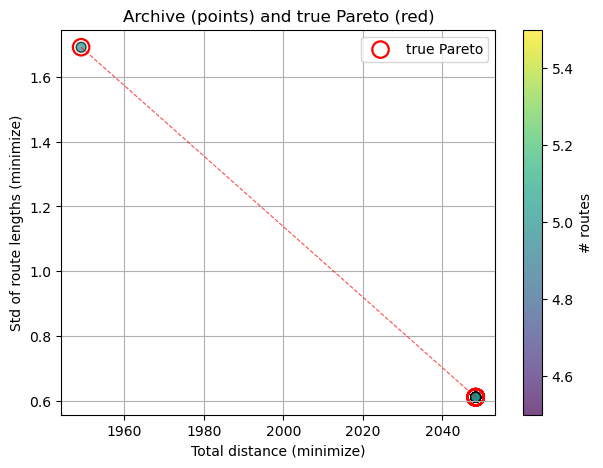

In [ ]:
# "Plot this pareto front "
# ensure `res` exists: res is list of (perm, (total,std), routes)
objs = np.array([obj for _, obj, _ in res])   # shape (N,2)
unique_objs, idx = np.unique(objs, axis=0, return_index=True)
print("archive size:", len(res))
print("unique objective vectors:", len(unique_objs))

def is_dominated(i, O):
    a = O[i]
    for j in range(len(O)):
        if j == i: continue
        b = O[j]
        if (b[0] <= a[0] and b[1] <= a[1]) and (b[0] < a[0] or b[1] < a[1]):
            return True
    return False

front_idx = [i for i in range(len(objs)) if not is_dominated(i, objs)]
print("non-dominated (true Pareto) count:", len(front_idx))
print("indices on true front:", front_idx)
print("unique non-dominated objective vectors:")
for i in front_idx:
    print(f"  idx={i} total={objs[i,0]:.2f} std={objs[i,1]:.2f} routes={len(res[i][2])}")

# Plot
totals = objs[:,0]; stds = objs[:,1]
route_counts = np.array([len(r) for _,_,r in res])

plt.figure(figsize=(7,5))
sc = plt.scatter(totals, stds, c=route_counts, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
plt.colorbar(sc, label='# routes')
pf_tot = totals[front_idx]; pf_std = stds[front_idx]
plt.scatter(pf_tot, pf_std, facecolors='none', edgecolors='r', s=140, linewidths=1.6, label='true Pareto')
if len(pf_tot) > 1:
    order = np.argsort(pf_tot)
    plt.plot(pf_tot[order], pf_std[order], color='r', linestyle='--', linewidth=0.8, alpha=0.7)
plt.xlabel('Total distance (minimize)')
plt.ylabel('Std of route lengths (minimize)')
plt.title('Archive (points) and true Pareto (red)')
plt.legend()
plt.grid(True)
plt.show()
